# Entrenamiento de modelo de predicción de categoría


## Importación de librerias necesarias


In [16]:
%load_ext IPython.extensions.autoreload
%autoreload 2


The IPython.extensions.autoreload extension is already loaded. To reload it, use:
  %reload_ext IPython.extensions.autoreload


In [17]:
import os
from pathlib import Path
import sys

def find_src_folder(current_path: Path, folder_name: str = 'src') -> Path:
    search_directories = [current_path] + list(current_path.parents)
    for parent in search_directories:
        if parent.name == folder_name:
            return parent.parent
    return current_path

src_path = find_src_folder(Path.cwd(), 'src')
sys.path.append(str(src_path))

print(f"JAVA_HOME: {os.environ.get('JAVA_HOME')}")
print(f"TFHUB_CACHE_DIR: {os.environ.get('TFHUB_CACHE_DIR')}")


JAVA_HOME: /usr/lib/jvm/java-11-openjdk-amd64
TFHUB_CACHE_DIR: /mnt/d/Maestría/Amazon Reviews Code/tf_cache


In [18]:
import numpy as np
import pandas as pd
import sys
import os
import shutil
import tensorflow as tf
import tensorflow_io as tfio
from pyspark.sql import functions as F, types as T, DataFrame
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from pyspark.ml.functions import array_to_vector, vector_to_array
from pyspark.ml.feature import VectorAssembler


In [19]:
print(f"Python executable: {sys.executable}")
print(f"Python version: {sys.version}")
print(f"TensorFlow version: {tf.__version__}")
print(f"CUDA built: {tf.test.is_built_with_cuda()}")

gpus = tf.config.list_physical_devices('GPU')
print(f"GPU devices: {gpus}")

if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU memory growth enabled")
    except RuntimeError as e:
        print(f"GPU memory growth error: {e}")

if gpus:
    with tf.device('/GPU:0'):
        a = tf.constant([[1.0, 2.0], [3.0, 4.0]])
        b = tf.constant([[2.0, 0.0], [0.0, 2.0]])
        c = tf.matmul(a, b)
        print(f"GPU test result: {c.numpy()}")
        print("✓ GPU is working!")
else:
    print("❌ No GPU detected")


Python executable: /mnt/d/Maestría/Amazon Reviews Code/.venv-linux/bin/python
Python version: 3.11.13 (main, Jun  4 2025, 08:57:30) [GCC 13.3.0]
TensorFlow version: 2.17.1
CUDA built: True
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU memory growth enabled
GPU test result: [[2. 4.]
 [6. 8.]]
✓ GPU is working!


In [20]:
from src.utils.spark import SparkUtils, METASTORE_PATH
spark_utils = SparkUtils('predict_category_model')
spark = spark_utils.spark


## Cargar datos fuente de entrenamiento


In [21]:
GOLD_ENCODING = 'gold.encoding'
GOLD_PREMODELING = 'gold.premodeling'
GOLD_SCHEMA_CLUSTER = 'gold.cluster'
SCHEMA = 'silver.preprocess'


In [22]:
REGENERATE_MODEL = False


In [23]:
src_dir_category_prediction = f"{METASTORE_PATH}/warehouse/gold.premodeling/final_training_data_category_prediction"
dst_dir_category_prediction = f"{METASTORE_PATH}/warehouse/gold.premodeling/dataset_score_model_category_prediction"
dst_path_category_prediction = os.path.join(dst_dir_category_prediction, "dataset_training.parquet")


In [24]:
categories = spark.read.parquet(src_dir_category_prediction).schema.names
categories = [bytes(c, 'utf-8') for c in categories if c.startswith("main_category_")]

In [25]:
from src.utils.models import CategoryPredictionModel


In [26]:
category_prediction_model = CategoryPredictionModel(
    'category_prediction_model', METASTORE_PATH, tracking_uri="file:///mnt/d/Maestría/Amazon Reviews Code/.mlflow",
    num_classes=len(categories)
)


In [27]:
category_prediction_model.prepare_data(
    spark, src_dir_category_prediction, dst_dir_category_prediction, dst_path_category_prediction, target_columns=categories, shuffle_buffer_size = -1,
    train_ratio=0.8, val_ratio=0.1
)


## Crear modelo de predicción


In [28]:
category_prediction_model.create_model()


<Sequential name=sequential_1, built=True>

In [29]:
category_prediction_model.model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 9)              │           297 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 437,513 (1.67 MB)

 Trainable params: 437,513 (1.67 MB)

 Non-trainable params: 0 (0.00 B)

In [30]:
if True:
    history_model_category_prediction = category_prediction_model.train(epochs=20)


Epoch 1/20


I0000 00:00:1760901891.259606  154784 service.cc:146] XLA service 0x72691802e810 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1760901891.259640  154784 service.cc:154]   StreamExecutor device (0): NVIDIA GeForce RTX 3050, Compute Capability 8.6
2025-10-19 14:24:51.295131: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-10-19 14:24:51.470960: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 8907


      8/Unknown 8s 27ms/step - accuracy: 0.2750 - loss: 2.1295

I0000 00:00:1760901894.478694  154784 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


     57/Unknown 12s 76ms/step - accuracy: 0.2456 - loss: 2.1205

...

2025-10-19 14:25:17.507247: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
	 [[IteratorGetNext/_4]]
2025-10-19 14:25:17.507276: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 9309443894047087503
2025-10-19 14:25:17.507290: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 2191474323861497842


55/57 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.2040 - loss: 2.1494
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 3: val_loss did not improve from 2.20382
57/57 ━━━━━━━━━━━━━━━━━━━━ 9s 111ms/step - accuracy: 0.1635 - loss: 2.1651 - val_accuracy: 0.0433 - val_loss: 2.2137 - learning_rate: 0.0010
Epoch 4/20


2025-10-19 14:25:26.069373: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 9309443894047087503
2025-10-19 14:25:26.069405: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 2191474323861497842


55/57 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.2167 - loss: 2.1252
Epoch 4: val_loss did not improve from 2.20382
57/57 ━━━━━━━━━━━━━━━━━━━━ 8s 108ms/step - accuracy: 0.1682 - loss: 2.1333 - val_accuracy: 0.0389 - val_loss: 2.2288 - learning_rate: 5.0000e-04
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 1.


2025-10-19 14:25:34.444455: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
	 [[IteratorGetNext/_4]]
2025-10-19 14:25:34.444480: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 9309443894047087503
2025-10-19 14:25:34.444490: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 2191474323861497842


2025/10/19 14:25:35 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/10/19 14:25:35 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.
2025/10/19 14:25:48 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


e68f9909197548ac840ce49c0f59c54c
Plot saved to /mnt/d/Maestría/Amazon Reviews Code/data/warehouse/gold.premodeling/training_history_category_prediction_model.png


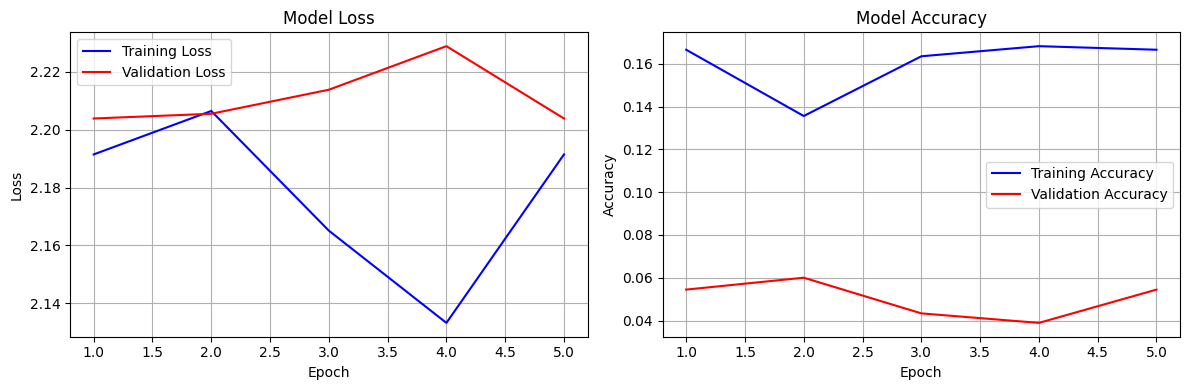

In [31]:
if True:
    for name, model in [
        ("category_prediction_model", category_prediction_model)
    ]:

        tags = {
            "model_type": "neural_network",
            "task": "rating_prediction",
            "dataset": "amazon_reviews",
            "variant": name
        }
 
        exp = model.log_training_history(
            run_name=f"{name}_{model.input_shape}features",
            tags=tags
        )

        print(exp)

        _ = model.plot_training_history(
            save_path=f"{METASTORE_PATH}/warehouse/gold.premodeling/training_history_{name}.png"
        )


## Cargar modelo


In [32]:
from src.utils.models import CategoryPredictionModel
categories = spark.read.parquet(src_dir_category_prediction).schema.names
categories = [bytes(c, 'utf-8') for c in categories if c.startswith("main_category_")]

category_prediction_model = CategoryPredictionModel('category_prediction_model', METASTORE_PATH, num_classes=len(categories), tracking_uri="file:///mnt/d/Maestría/Amazon Reviews Code/.mlflow")
category_prediction_model.load_latest_model()


/mnt/d/Maestría/Amazon Reviews Code/.venv-linux/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 14 variables whereas the saved optimizer has 26 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [33]:
category_prediction_model.list_available_models()



Available Model Versions (filtered by: category_prediction_model)

1. Run ID: e68f9909197548ac840ce49c0f59c54c
   Run Name: category_prediction_model_512features
   Model Name: 
   Status: FINISHED
   Start Time: 2025-10-19 19:25:35.485000+00:00
   End Time: 2025-10-19 19:25:48.738000+00:00
   Metrics: Loss: 2.1333, Val Loss: 2.2288, Accuracy: 0.1682, Val Accuracy: 0.0389

2. Run ID: 7e50f160b6f74f42914b2a12f8c31d39
   Run Name: category_prediction_model_512features
   Model Name: 
   Status: FINISHED
   Start Time: 2025-10-19 17:48:50.935000+00:00
   End Time: 2025-10-19 17:49:04.779000+00:00
   Metrics: Loss: 0.7192, Val Loss: 1.1659, Accuracy: 0.7325, Val Accuracy: 0.6700



In [34]:
X_test, y_test = next(iter(category_prediction_model.val_dataset.take(1)))


AttributeError: 'NoneType' object has no attribute 'take'

In [ ]:
X_test.shape


In [ ]:
y_pred = category_prediction_model.predict(X_test.numpy())


In [ ]:
def predict_rating(model, features):
    if len(features.shape) == 1:
        features = features.reshape(1, -1)
    probabilities = model.predict(features, verbose=0)
    predictions = np.argmax(probabilities, axis=1)
    return predictions, probabilities

test_batch = next(iter(category_prediction_model.val_dataset.take(1)))
X_test, y_test = test_batch
predictions, probabilities = predict_rating(category_prediction_model.model, X_test.numpy())


In [ ]:
category_prediction_model.get_model_versions()


## Get training history


## Plot training history


In [ ]:
category_prediction_model.get_latest_model_history()


In [ ]:
category_prediction_model.plot_latest_model_history()
